# Neural Networks: Multi-layered and Multi-class classification

### Welcome to the 4th Lab of 42028: Deep Learning and CNN!

In this  Lab/Tutorial session you will be implementing Neural Network for Fashion MNIST dataset classification .

So lets get started!


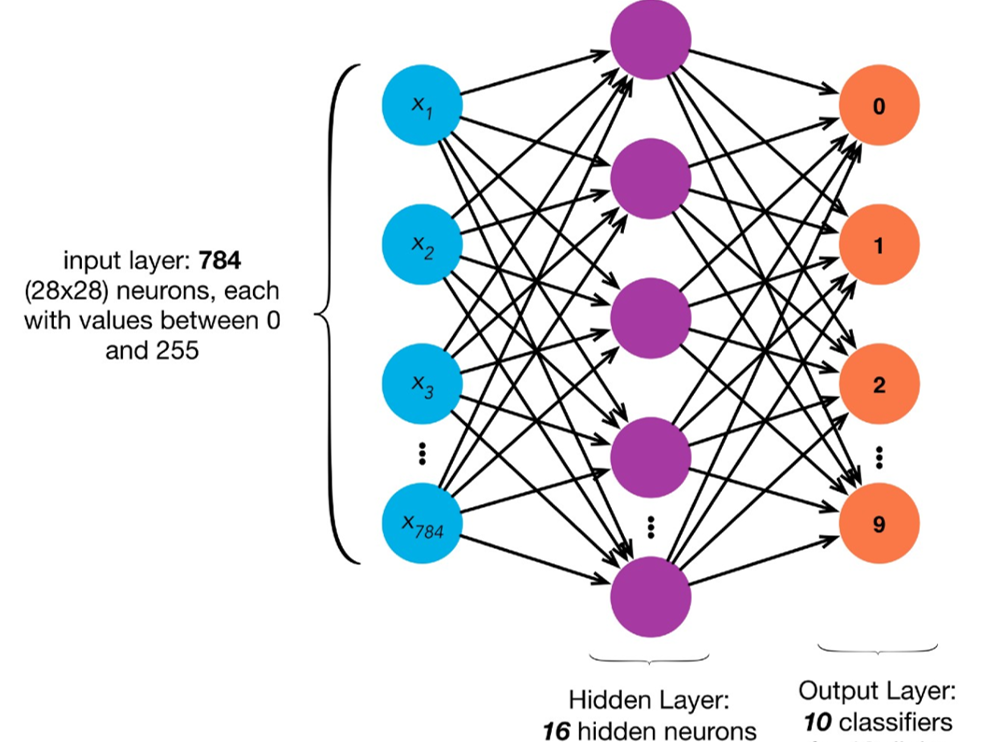


**Image source:** https://towardsdatascience.com/multi-layer-neural-networks-with-sigmoid-function-deep-learning-for-rookies-2-bf464f09eb7f


## Tasks for this week:

1. Implementation of Neural Network for classification using Keras API.
2. Train and test model


### Step 1: Import required packages

we will need tensorflow, numpy, os and keras


In [1]:
!pip install opencv-python-headless

In [2]:
import tensorflow as tf
import os
import numpy as np

%load_ext tensorboard

2026-03-16 09:20:14.017643: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
from tensorflow import keras
print(tf.__version__)
print(keras.__version__)

2.18.0
3.12.0


### Step 2: Download the Fashion Mnist dataset using keras

In [4]:
fashionMnist=tf.keras.datasets.fashion_mnist

In [5]:
(train_images, train_labels), (test_images, test_labels) = fashionMnist.load_data()

In [6]:
print(train_images.shape)
print(train_images.dtype)

(60000, 28, 28)
uint8


In [7]:
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

3


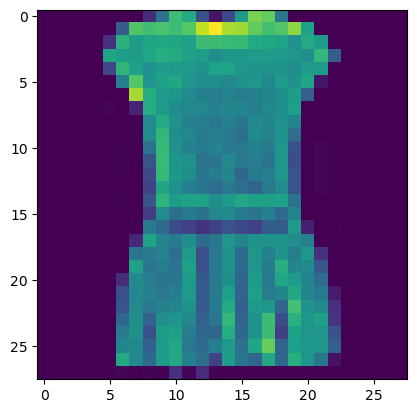

In [8]:
## Show an image from theh dataset
import matplotlib.pyplot as plt
plt.imshow(train_images[3])
print(train_labels[3])

** Note :** Scikit-learn import the Fashion MNIST dataset as a 1-D array while Keras API load the dataset in 28X28 format.

### Step 3: Normalize the dataset and split the small part of the training set into validation set


- Validation set: first 5000 samples
- Training set: 5000 to remaining

In [9]:
## WRITE YOUR CODE HERE ## (~ 5 line of code)
## Hint: Using slicing to split the training to train and validation

valid_images = train_images[:5000]
valid_labels = train_labels[:5000]


train_images = train_images[5000:]
train_labels = train_labels[5000:]

## Normalize the test images
test_images = test_images / 255.0
train_images = train_images / 255.0

### END YOUR CODE HERE ###

In [10]:
print(np.shape(train_images))
print(np.shape(valid_images))
print(np.shape(test_images))

(55000, 28, 28)
(5000, 28, 28)
(10000, 28, 28)


[**Expected** Output]

(55000, 28, 28)
(5000, 28, 28)
(10000, 28, 28)

### Step 4:  Design the model

In [11]:
model = tf.keras.models.Sequential([tf.keras.layers.Flatten(input_shape=[28,28]),
                                    tf.keras.layers.Dense(128, activation=tf.nn.relu),
                                    tf.keras.layers.Dense(10, activation=tf.nn.softmax)])

/opt/conda/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


## **Notes:**
* **Sequential model.** This is the simplest kind of Keras model, for neural networks which defines a SEQUENCE of layers.

* **Flatten.** Flatten just takes that image and turns it into a 1-dimensional vector.

* Next we add a second Dense hidden layer with 128 neurons, also using the ReLU activation function.  **Dense.** Add a layer to the neural network which is followed by activation function of ReLU. The ReLU only passes the value greater than 0 and for all other values of X it passes 0.
e.g. If X>0 return X, else return 0"

* Finally, we add a Dense output layer with 10 neurons (one per class), using the softmax activation function.

* **Softmax** The softmax takes a set of values and select the biggest one from the set of values.

## Step 5: Training the model

**"sparse_categorical_crossentropy":**   The dataset contains sparse labels and the classes are exclusive.

**One-hot vector encoding** This is sometime used for encoding the labels if there one target  probability per class for each instance. For example.
[0., 0., 0., 0., 1., 0., 0., 0., 0., 0.] represent one-hot encoding for class 4. In such case, **"categorical_crossentropy"** loss is used.

**"sigmoid_crossentropy"** This loss is used for binary class classification problems and also **"sigmoid"** activation function is used instead of Softmax.



#### Visualize the model

In [12]:
!pip install pydot

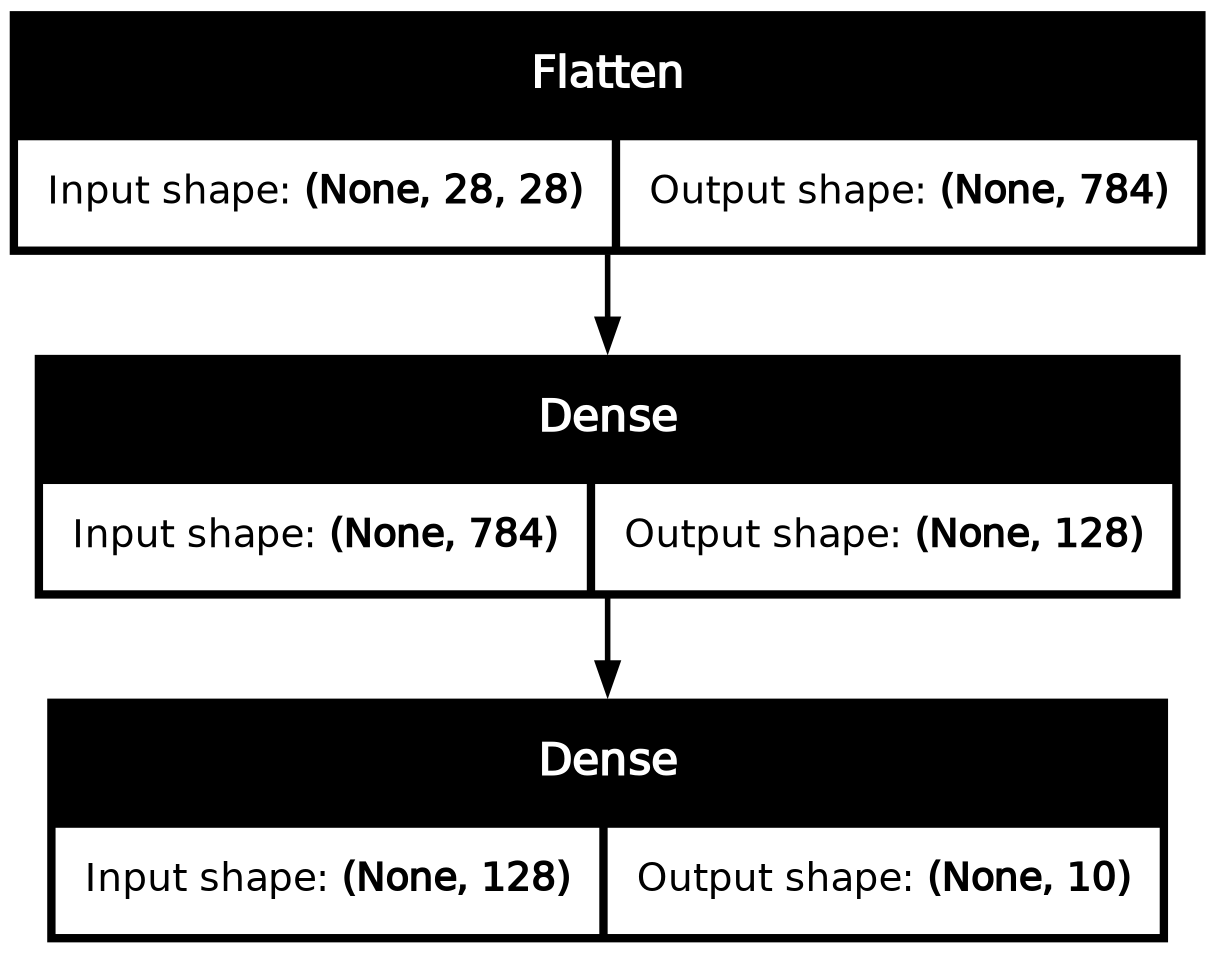

In [13]:
#Visualize Network Model
modelViz_file= 'model_1.png' # Model filename

# Plot model
keras.utils.plot_model(model, to_file=modelViz_file, show_shapes=True)

In [14]:
model.compile(optimizer = tf.optimizers.Adam(),
              loss = 'sparse_categorical_crossentropy',
              metrics=['accuracy'])

H=model.fit(train_images, train_labels, epochs=10,validation_data=(valid_images, valid_labels))

Epoch 1/10


2026-03-16 09:20:26.807715: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 172480000 exceeds 10% of free system memory.


1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8208 - loss: 0.5091 - val_accuracy: 0.8508 - val_loss: 57.1865
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8618 - loss: 0.3854 - val_accuracy: 0.8630 - val_loss: 49.1864
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8747 - loss: 0.3439 - val_accuracy: 0.8626 - val_loss: 52.4854
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8815 - loss: 0.3206 - val_accuracy: 0.8740 - val_loss: 46.4121
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8906 - loss: 0.2976 - val_accuracy: 0.8754 - val_loss: 47.2516
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8945 - loss: 0.2840 - val_accuracy: 0.8648 - val_loss: 57.0564
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8979 - loss: 0.2708 - val_accuracy: 0.8824 - val_loss: 48.5051
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9035 - loss: 0.2607 - v

Why do we use validation dataset?

In [15]:
type(H)
print(H.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


## Task:

Change the Optimizer to SGD or any other optimizer and retrain the model.

#### Optional: Add another layer and retain to check the accuracy

Reference:

https://www.tensorflow.org/api_docs/python/tf/train/GradientDescentOptimizer


https://www.tensorflow.org/api_docs/python/tf/train/Optimizer

In [16]:
## WRITE YOUR CODE HERE ## (~ 3 line of code)

model1 =  tf.keras.models.Sequential([tf.keras.layers.Flatten(input_shape=[28,28]),
                                    tf.keras.layers.Dense(128, activation=tf.nn.relu),
                                    tf.keras.layers.Dense(10, activation=tf.nn.softmax)]) ## create a model here

model1.compile(optimizer = tf.optimizers.SGD(), loss = 'sparse_categorical_crossentropy', metrics = ['accuracy']) ## add the required arguments

H=model1.fit(train_images, train_labels, epochs = 10, validation_data = (valid_images, valid_labels)) ## Add the required arguments

### END YOUR CODE HERE ###

/opt/conda/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10


2026-03-16 09:21:46.202374: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 172480000 exceeds 10% of free system memory.


1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7540 - loss: 0.7581 - val_accuracy: 0.7944 - val_loss: 65.1646
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8227 - loss: 0.5215 - val_accuracy: 0.8044 - val_loss: 68.0331
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8363 - loss: 0.4752 - val_accuracy: 0.8170 - val_loss: 67.1520
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8446 - loss: 0.4494 - val_accuracy: 0.8340 - val_loss: 59.6517
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8510 - loss: 0.4313 - val_accuracy: 0.8202 - val_loss: 69.8601
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8555 - loss: 0.4172 - val_accuracy: 0.8098 - val_loss: 81.3598
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8593 - loss: 0.4046 - val_accuracy: 0.8310 - val_loss: 66.6459
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8627 - loss: 0.3950 - val_

### Summary of the model

In [17]:
## Use model.summary to great a summary for the model(layers, type, shape, etc.)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 305,312 (1.16 MB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 203,542 (795.09 KB)

#### Visualize the model

In [18]:
# Intsall pydot library
!pip install pydot

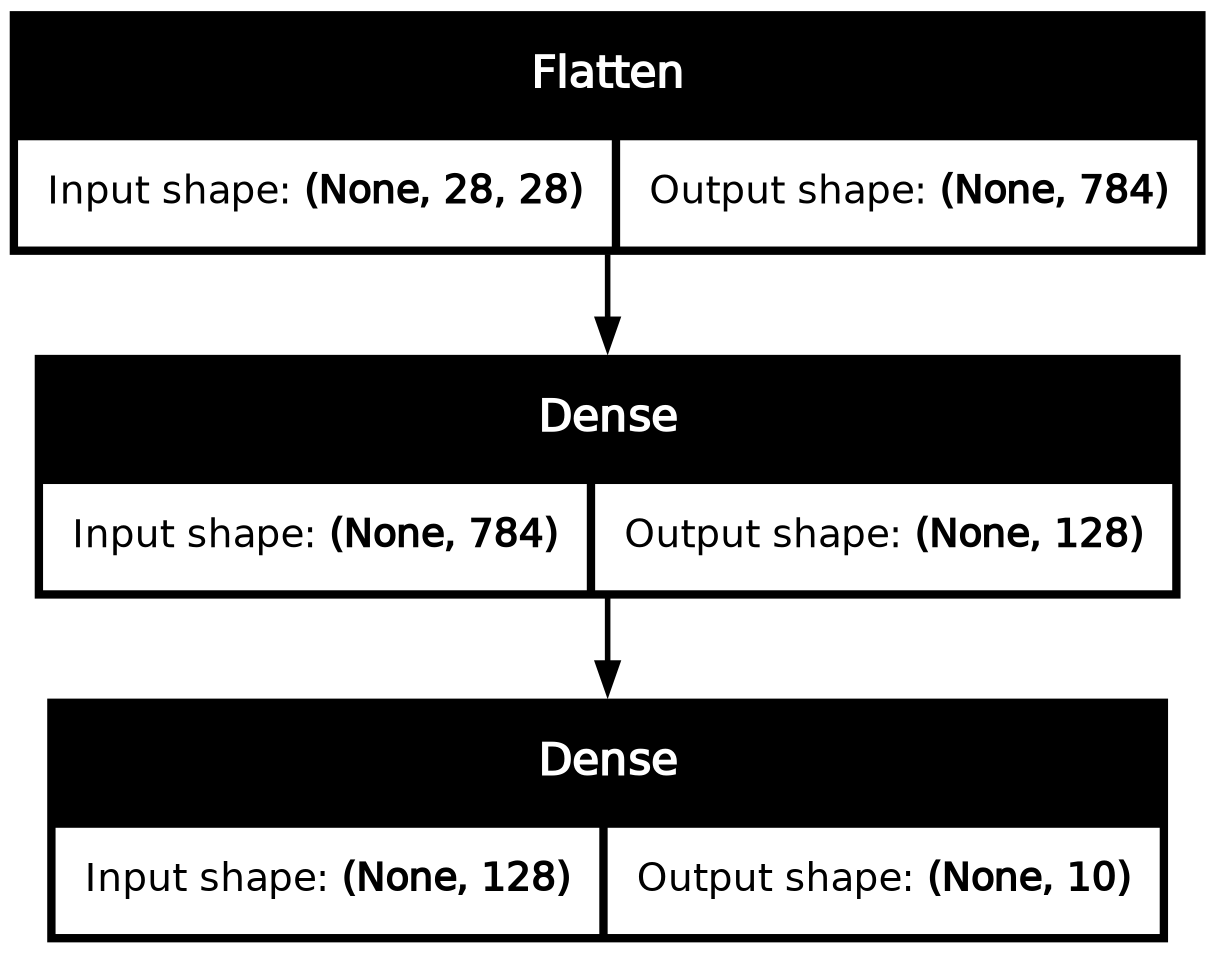

In [19]:
#Visualize Network Model
import pydot

modelViz_file= 'model_1.png' # Model filename

# Plot model
keras.utils.plot_model(model, to_file=modelViz_file, show_shapes=True)

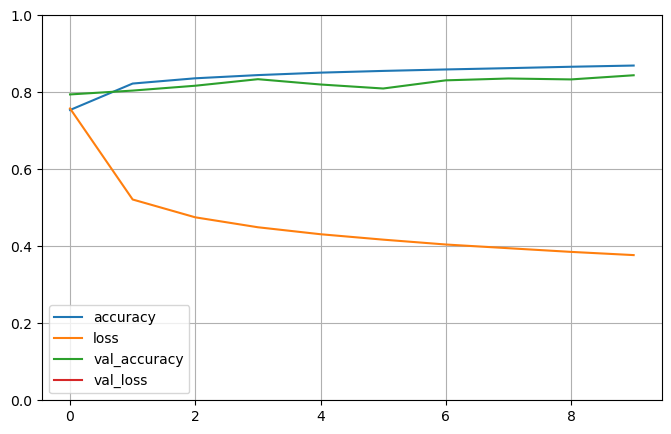

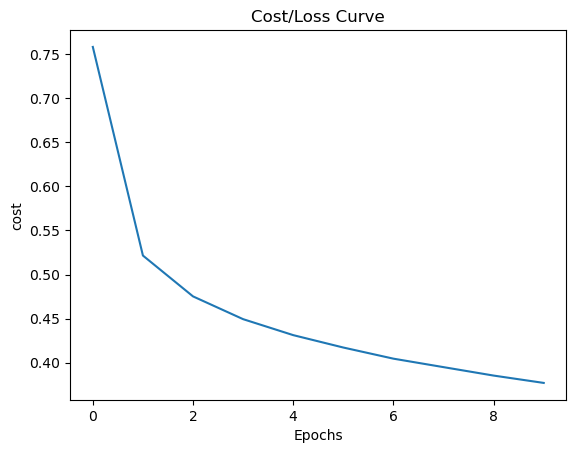

In [20]:
## Plot the learning curves
import pandas as pd
import matplotlib.pyplot as plt
pd.DataFrame(H.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1) # set the vertical range to [0-1]
plt.show()

## Plot only the loss train loss
plt.plot(H.history['loss'])
plt.ylabel('cost')
plt.xlabel('Epochs')
plt.title("Cost/Loss Curve")
plt.show()

## Step 6: Evaluation on test dataset

In [21]:
## Evaluate the model's performance on test dataset.
model.evaluate(test_images, test_labels)

 32/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8757 - loss: 0.3887   

2026-03-16 09:22:40.080324: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 31360000 exceeds 10% of free system memory.


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8780 - loss: 0.3556


[0.35556650161743164, 0.878000020980835]

## Task:

Evaluate the model trained with SGD


In [25]:
## WRITE YOUR CODE HERE ## (~ 1 line of code)
model1.evaluate(test_images, test_labels)

  1/313 ━━━━━━━━━━━━━━━━━━━━ 45s 146ms/step - accuracy: 0.8438 - loss: 0.3904

2026-03-16 09:28:41.606310: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 31360000 exceeds 10% of free system memory.


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8489 - loss: 0.4250


[0.4249829649925232, 0.8489000201225281]

### Callbacks for early stopping training

In [23]:
class myCallback(tf.keras.callbacks.Callback):
  def on_epoch_end(self, epoch, logs={}):
    if(logs.get('loss')<0.1):
      print("\nReached 60% accuracy so cancelling training!")
      self.model.stop_training = True

In [24]:
callbacks = myCallback()
model = tf.keras.models.Sequential([
  tf.keras.layers.Flatten(input_shape=[28,28]),
  tf.keras.layers.Dense(512, activation=tf.nn.relu),
  tf.keras.layers.Dense(10, activation=tf.nn.softmax)
])
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy')
model.fit(train_images, train_labels, epochs=5, callbacks=[callbacks])

/opt/conda/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
2026-03-16 09:22:41.286859: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 172480000 exceeds 10% of free system memory.


Epoch 1/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - loss: 0.4783
Epoch 2/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - loss: 0.3631
Epoch 3/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step - loss: 0.3267
Epoch 4/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - loss: 0.3030
Epoch 5/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - loss: 0.2836
